In [56]:
import requests
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.patches import Circle
from IPython.display import HTML
from matplotlib.collections import LineCollection
import matplotlib.colors as cm
import matplotlib.gridspec as gridspec

print("All good! 🚀")

All good! 🚀


In [36]:
url = "https://ssd.jpl.nasa.gov/api/horizons.api"

params = {
    "format": "json",
    "COMMAND": "-1024",
    "OBJ_DATA": "NO",
    "MAKE_EPHEM": "YES",
    "EPHEM_TYPE": "VECTORS",
    "CENTER": "500@399",
    "START_TIME": "'2026-Apr-02 02:00'",   # ← after separation
    "STOP_TIME": "'2026-Apr-10 00:00'",
    "STEP_SIZE": "1h",
    "VEC_TABLE": "2",
}

response = requests.get(url, params=params)
data = response.json()

print(data.keys())
print("---")
print(data['result'][:800])

dict_keys(['result', 'signature'])
---


*******************************************************************************
Ephemeris / API_USER Wed Apr  1 11:42:56 2026 Pasadena, USA      / Horizons
*******************************************************************************
Target body name: Artemis II (spacecraft) (-1024) {source: Artemis_II_merged}
Center body name: Earth (399)                     {source: DE441}
Center-site name: BODY CENTER
*******************************************************************************
Start time      : A.D. 2026-Apr-02 02:00:00.0000 TDB
Stop  time      : A.D. 2026-Apr-10 00:00:00.0000 TDB
Step-size       : 60 minutes
*******************************************************************************
Center geodetic : 0.0, 0.0, 0.0                   {E-lon(deg),Lat(deg),Alt(km)}
Center cylind


In [37]:
# Print a bigger chunk to see the actual vector data
print(data['result'][800:2000])


ric: 0.0, 0.0, 0.0                   {E-lon(deg),Dxy(km),Dz(km)}
Center radii    : 6378.137, 6378.137, 6356.752 km {Equator_a, b, pole_c}
Output units    : KM-S
Calendar mode   : Mixed Julian/Gregorian
Output type     : GEOMETRIC cartesian states
Output format   : 2 (position and velocity)
EOP file        : eop.260331.p260627
EOP coverage    : DATA-BASED 1962-JAN-20 TO 2026-MAR-31. PREDICTS-> 2026-JUN-26
Reference frame : Ecliptic of J2000.0
*******************************************************************************
JDTDB
   X     Y     Z
   VX    VY    VZ
*******************************************************************************
$$SOE
2461132.583333333 = A.D. 2026-Apr-02 02:00:00.0000 TDB 
 X =-2.568496842018601E+04 Y =-1.702676695597623E+04 Z =-1.456979346358436E+03
 VX=-1.571254043991839E+00 VY=-3.698789680975732E+00 VZ=-3.200781010121481E-01
2461132.625000000 = A.D. 2026-Apr-02 03:00:00.0000 TDB 
 X =-2.960616488997024E+04 Y =-2.901847394429912E+04 Z =-2.495528778089021E+0

In [38]:
raw = data['result']

soe = raw.index('$$SOE')
eoe = raw.index('$$EOE')
ephem_block = raw[soe+6:eoe]

records = []
lines = [l.strip() for l in ephem_block.strip().split('\n') if l.strip()]

for i in range(0, len(lines), 3):
    time_line = lines[i]
    pos_line  = lines[i+1]
    vel_line  = lines[i+2]

    dt_match = re.search(r'A\.D\.\s+([\d\-A-Za-z]+\s[\d:\.]+)\s+TDB', time_line)
    dt_str = dt_match.group(1) if dt_match else None

    x  = float(re.search(r'X\s*=\s*([-\dE.+]+)', pos_line).group(1))
    y  = float(re.search(r'Y\s*=\s*([-\dE.+]+)', pos_line).group(1))
    z  = float(re.search(r'Z\s*=\s*([-\dE.+]+)', pos_line).group(1))
    vx = float(re.search(r'VX\s*=\s*([-\dE.+]+)', vel_line).group(1))
    vy = float(re.search(r'VY\s*=\s*([-\dE.+]+)', vel_line).group(1))
    vz = float(re.search(r'VZ\s*=\s*([-\dE.+]+)', vel_line).group(1))

    records.append({'time': dt_str,
                    'x': x, 'y': y, 'z': z,
                    'vx': vx, 'vy': vy, 'vz': vz})

df = pd.DataFrame(records)
df['time'] = pd.to_datetime(df['time'], format='%Y-%b-%d %H:%M:%S.%f')
df['dist_earth'] = np.sqrt(df['x']**2 + df['y']**2 + df['z']**2)

print(df.shape)
print(df.head())

(191, 8)
                 time             x             y            z        vx  \
0 2026-04-02 02:00:00 -25684.968420 -17026.766956 -1456.979346 -1.571254   
1 2026-04-02 03:00:00 -29606.164890 -29018.473944 -2495.528778 -0.712617   
2 2026-04-02 04:00:00 -31233.876768 -38869.440774 -3335.819010 -0.237403   
3 2026-04-02 05:00:00 -31520.507076 -47091.151136 -4031.753697  0.059601   
4 2026-04-02 06:00:00 -30905.200867 -53977.486169 -4613.326581  0.271647   

         vy        vz    dist_earth  
0 -3.698790 -0.320078  30850.464900  
1 -3.004740 -0.259594  41531.006410  
2 -2.492567 -0.211220  49975.155552  
3 -2.088035 -0.176538  56809.980809  
4 -1.745893 -0.147267  62369.730125  


In [55]:
moon_params = {
    "format": "json",
    "COMMAND": "301",              # Moon
    "OBJ_DATA": "NO",
    "MAKE_EPHEM": "YES",
    "EPHEM_TYPE": "VECTORS",
    "CENTER": "500@399",           # relative to Earth center, same as Orion
    "START_TIME": "'2026-Apr-02 02:00'",
    "STOP_TIME": "'2026-Apr-10 00:00'",
    "STEP_SIZE": "1h",
    "VEC_TABLE": "2",
}

moon_response = requests.get(url, params=moon_params)
moon_data = moon_response.json()

# Parse same way
raw_moon = moon_data['result']
soe = raw_moon.index('$$SOE')
eoe = raw_moon.index('$$EOE')
moon_block = raw_moon[soe+6:eoe]

moon_records = []
moon_lines = [l.strip() for l in moon_block.strip().split('\n') if l.strip()]

for i in range(0, len(moon_lines), 3):
    pos_line = moon_lines[i+1]
    mx = float(re.search(r'X\s*=\s*([-\dE.+]+)', pos_line).group(1))
    my = float(re.search(r'Y\s*=\s*([-\dE.+]+)', pos_line).group(1))
    mz = float(re.search(r'Z\s*=\s*([-\dE.+]+)', pos_line).group(1))
    moon_records.append({'mx': mx, 'my': my, 'mz': mz})

moon_df = pd.DataFrame(moon_records)
moon_df['dist_earth'] = np.sqrt(moon_df['mx']**2 + moon_df['my']**2 + moon_df['mz']**2)

# Merge with Orion df
df['mx'] = moon_df['mx']
df['my'] = moon_df['my']
df['mz'] = moon_df['mz']
df['dist_moon'] = np.sqrt((df['x']-df['mx'])**2 +
                           (df['y']-df['my'])**2 +
                           (df['z']-df['mz'])**2)

# Run this first to know our color scale bounds
df['speed'] = np.sqrt(df['vx']**2 + df['vy']**2 + df['vz']**2)
print(f"Max speed: {df['speed'].max():.2f} km/s")  # near Earth
print(f"Min speed: {df['speed'].min():.2f} km/s")  # far from Earth
print(f"Speed at lunar flyby: {df['speed'][df['dist_moon'].idxmin()]:.2f} km/s")

speed_min = df['speed'].min()
speed_max = df['speed'].max()

# Normalize speeds to 0-1 for colormap
# We use 'plasma' — blue(slow) → orange → red(fast)
cmap = plt.cm.plasma
norm = mcolors.Normalize(vmin=speed_min, vmax=speed_max)

# Pre-build all trail segments for the full trajectory (faint background)
points = np.array([df['x'], df['y']]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
speeds_norm = norm(df['speed'].values[:-1])
colors_full = cmap(speeds_norm)
colors_full[:, 3] = 0.15  # very faint alpha for background trail

full_trail = LineCollection(segments, colors=colors_full, linewidth=1.2, zorder=2)
ax.add_collection(full_trail)

# Colorbar legend
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.3, pad=0.02, location='right')
cbar.set_label('Speed (km/s)', color='#4a7a9b', fontsize=8, fontfamily='monospace')
cbar.ax.yaxis.set_tick_params(color='#4a7a9b')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#4a7a9b',
         fontsize=7, fontfamily='monospace')
cbar.outline.set_edgecolor('#0d2a45')

print(df[['time', 'dist_earth', 'dist_moon']].head(10))
print(f"\nClosest Moon approach: {df['dist_moon'].min():.0f} km at {df.loc[df['dist_moon'].idxmin(), 'time']}")
print(f"Max Earth distance: {df['dist_earth'].max():.0f} km at {df.loc[df['dist_earth'].idxmax(), 'time']}")

# Find key mission moment frames
tli_time        = pd.Timestamp('2026-04-02 03:00')   # Trans-Lunar Injection burn
prox_ops_time   = pd.Timestamp('2026-04-02 04:00')   # Proximity operations
outer_belt_exit = pd.Timestamp('2026-04-03 03:00')   # Exit outer belt
lunar_flyby     = df.loc[df['dist_moon'].idxmin(), 'time']  # Closest Moon approach
splashdown_time = pd.Timestamp('2026-04-10 18:00')   # Approximate splashdown

# Find frame indices
def find_frame(t):
    return (df['time'] - t).abs().idxmin()

tli_idx        = find_frame(tli_time)
prox_idx       = find_frame(prox_ops_time)
belt_exit_idx  = find_frame(outer_belt_exit)
flyby_idx      = find_frame(lunar_flyby)
splash_idx     = find_frame(splashdown_time)

print(f"TLI Burn        → frame {tli_idx}  | {df['time'][tli_idx]}")
print(f"Proximity Ops   → frame {prox_idx}  | {df['time'][prox_idx]}")
print(f"Belt Exit       → frame {belt_exit_idx} | {df['time'][belt_exit_idx]}")
print(f"Lunar Flyby     → frame {flyby_idx} | {df['time'][flyby_idx]}")
print(f"Splashdown      → frame {splash_idx} | {df['time'][splash_idx]}")

Max speed: 7.79 km/s
Min speed: 0.41 km/s
Speed at lunar flyby: 0.41 km/s
                 time    dist_earth      dist_moon
0 2026-04-02 02:00:00  30850.464900  365066.801746
1 2026-04-02 03:00:00  41531.006410  359153.284989
2 2026-04-02 04:00:00  49975.155552  355938.625614
3 2026-04-02 05:00:00  56809.980809  354327.104095
4 2026-04-02 06:00:00  62369.730125  353793.599207
5 2026-04-02 07:00:00  66849.411735  354048.002857
6 2026-04-02 08:00:00  70375.481956  354908.934464
7 2026-04-02 09:00:00  73032.532362  356256.504136
8 2026-04-02 10:00:00  74877.099794  358009.073539
9 2026-04-02 11:00:00  75945.250349  360110.617023

Closest Moon approach: 8361 km at 2026-04-06 23:00:00
Max Earth distance: 413214 km at 2026-04-06 23:00:00
TLI Burn        → frame 1  | 2026-04-02 03:00:00
Proximity Ops   → frame 2  | 2026-04-02 04:00:00
Belt Exit       → frame 25 | 2026-04-03 03:00:00
Lunar Flyby     → frame 117 | 2026-04-06 23:00:00
Splashdown      → frame 190 | 2026-04-10 00:00:00


<Figure size 640x480 with 0 Axes>

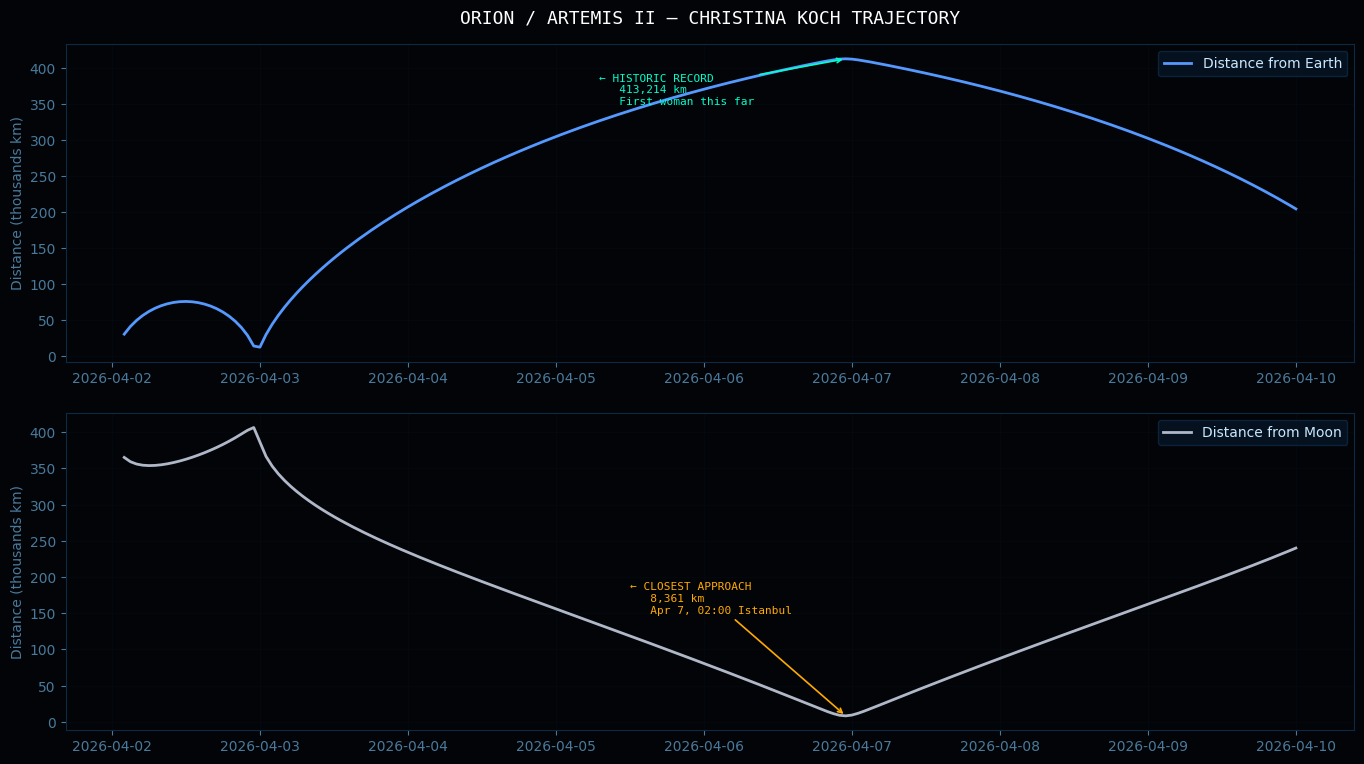

In [46]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), facecolor='#020408')

for ax in [ax1, ax2]:
    ax.set_facecolor('#020408')
    ax.tick_params(colors='#4a7a9b')
    ax.spines['bottom'].set_color('#0d2a45')
    ax.spines['top'].set_color('#0d2a45')
    ax.spines['left'].set_color('#0d2a45')
    ax.spines['right'].set_color('#0d2a45')

# Distance from Earth
ax1.plot(df['time'], df['dist_earth']/1000,
         color='#5599ff', linewidth=2, label='Distance from Earth')
ax1.set_ylabel('Distance (thousands km)', color='#4a7a9b', fontsize=10)
ax1.set_title('ORION / ARTEMIS II — CHRISTINA KOCH TRAJECTORY',
              color='white', fontsize=13, pad=15,
              fontfamily='monospace')
ax1.legend(facecolor='#071525', edgecolor='#0d2a45', labelcolor='#c8e8ff')
ax1.grid(alpha=0.1, color='#0d2a45')

# Mark historic max distance
max_idx = df['dist_earth'].idxmax()
ax1.annotate('← HISTORIC RECORD\n   413,214 km\n   First woman this far',
             xy=(df['time'][max_idx], df['dist_earth'][max_idx]/1000),
             xytext=(df['time'][max_idx-40], 350),
             color='#00ffcc', fontsize=8, fontfamily='monospace',
             arrowprops=dict(arrowstyle='->', color='#00ffcc', lw=1.2))

# Distance from Moon
ax2.plot(df['time'], df['dist_moon']/1000,
         color='#b0b8c8', linewidth=2, label='Distance from Moon')
min_idx = df['dist_moon'].idxmin()
ax2.annotate(f'← CLOSEST APPROACH\n   8,361 km\n   Apr 7, 02:00 Istanbul',
             xy=(df['time'][min_idx], df['dist_moon'][min_idx]/1000),
             xytext=(df['time'][min_idx-35], 150),
             color='#ffaa00', fontsize=8, fontfamily='monospace',
             arrowprops=dict(arrowstyle='->', color='#ffaa00', lw=1.2))
ax2.set_ylabel('Distance (thousands km)', color='#4a7a9b', fontsize=10)
ax2.legend(facecolor='#071525', edgecolor='#0d2a45', labelcolor='#c8e8ff')
ax2.grid(alpha=0.1, color='#0d2a45')

plt.tight_layout(pad=2)
plt.savefig('koch_trajectory.png', dpi=150, bbox_inches='tight',
            facecolor='#020408')
plt.show()

/tmp/ipykernel_8783/795484247.py:190: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_8783/795484247.py:194: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) DejaVu Sans Mono.
  html_content = anim.to_jshtml()


Saving... this takes ~30-60 seconds ⏳
Done! ✅


/content/artemis_ii_koch.html

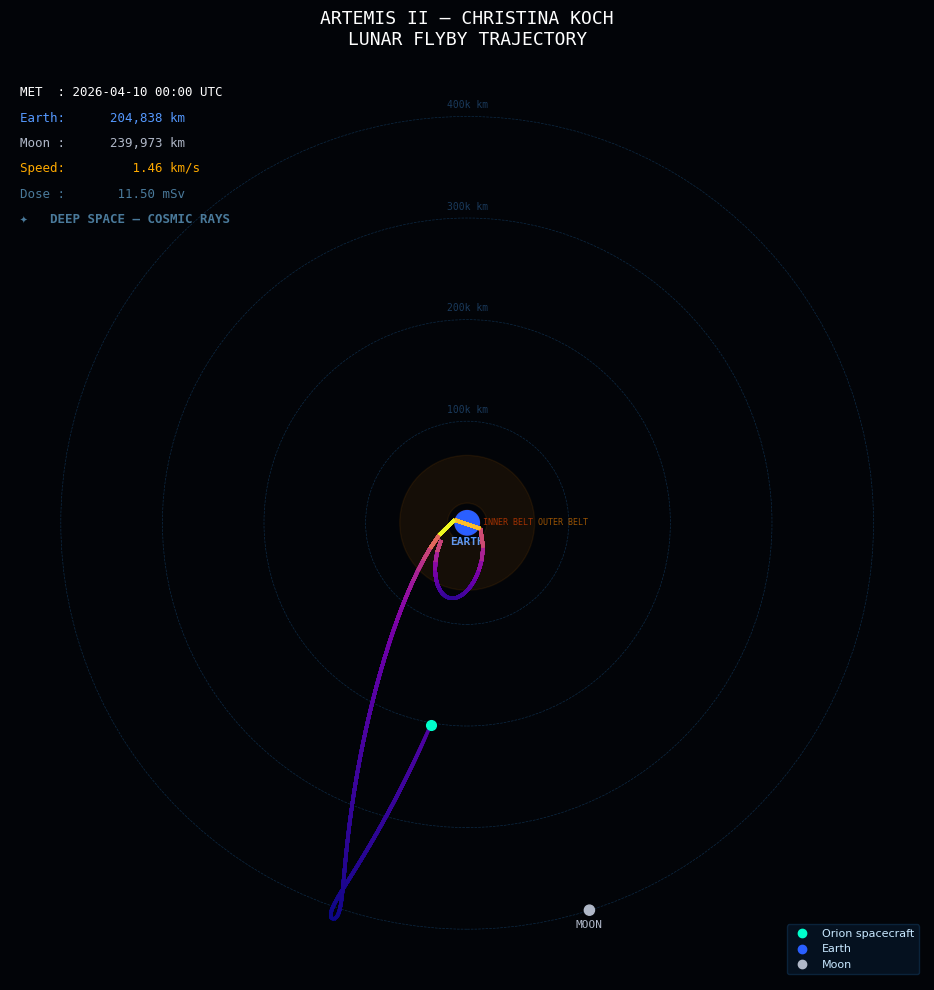

In [54]:
plt.rcParams['animation.embed_limit'] = 50

fig, ax = plt.subplots(figsize=(10, 10), facecolor='#020408')
ax.set_facecolor('#020408')
ax.set_aspect('equal')

limit = 450000
ax.set_xlim(-limit, limit)
ax.set_ylim(-limit, limit)
ax.axis('off')

# Distance rings
for r in [100000, 200000, 300000, 400000]:
    circle = plt.Circle((0, 0), r, color='#0d2a45',
                         fill=False, linewidth=0.5, linestyle='--')
    ax.add_patch(circle)
    ax.text(0, r+8000, f'{r//1000}k km', color='#1a3a5c',
            fontsize=7, ha='center', fontfamily='monospace')

# Earth
earth = plt.Circle((0, 0), 12000, color='#2a5fff', zorder=5)
ax.add_patch(earth)
ax.text(0, -22000, 'EARTH', color='#5599ff', fontsize=8,
        ha='center', fontfamily='monospace', fontweight='bold')

# Faint full trajectory
ax.plot(df['x'], df['y'], color='#00aaff', linewidth=0.8, alpha=0.2, zorder=2)

# Van Allen Belt boundaries (from Earth center in km)
INNER_START = 7371
INNER_END   = 12371
OUTER_START = 19371
OUTER_END   = 66371

# Inner belt — drawn but Orion already past it at frame 0
# Still draw it for context
inner_belt = plt.matplotlib.patches.Annulus(
    (0, 0), INNER_END, INNER_END - INNER_START,
    color='#ff4400', alpha=0.15, zorder=3
)
ax.add_patch(inner_belt)
ax.text(INNER_END + 3000, 0, 'INNER BELT', color='#ff4400',
        fontsize=6, fontfamily='monospace', alpha=0.6, va='center')

# Outer belt
outer_belt = plt.matplotlib.patches.Annulus(
    (0, 0), OUTER_END, OUTER_END - OUTER_START,
    color='#ff8800', alpha=0.08, zorder=3
)
ax.add_patch(outer_belt)
ax.text(OUTER_END + 3000, 0, 'OUTER BELT', color='#ff8800',
        fontsize=6, fontfamily='monospace', alpha=0.6, va='center')

# Moon
moon_patch = plt.Circle((df['mx'][0], df['my'][0]), 5000,
                          color='#b0b8c8', zorder=5)
ax.add_patch(moon_patch)
moon_label = ax.text(0, 0, 'MOON', color='#b0b8c8', fontsize=8,
                     ha='center', fontfamily='monospace', zorder=6)

# Orion
orion_dot, = ax.plot([], [], 'o', color='#00ffcc', markersize=7, zorder=10)
orion_trail, = ax.plot([], [], '-', color='#00ffcc', linewidth=1.5,
                        alpha=0.7, zorder=9)

# Info texts
time_text       = ax.text(-440000, 420000, '', color='white',
                           fontsize=9, fontfamily='monospace', zorder=11)
dist_earth_text = ax.text(-440000, 395000, '', color='#5599ff',
                           fontsize=9, fontfamily='monospace', zorder=11)
dist_moon_text  = ax.text(-440000, 370000, '', color='#b0b8c8',
                           fontsize=9, fontfamily='monospace', zorder=11)
speed_text      = ax.text(-440000, 345000, '', color='#ffaa00',
                           fontsize=9, fontfamily='monospace', zorder=11)
record_text     = ax.text(0, 0, '', color='#00ffcc', fontsize=10,
                           fontfamily='monospace', ha='center',
                           fontweight='bold', zorder=12)
rad_text    = ax.text(-440000, 320000, '', color='#ff4400',
                       fontsize=9, fontfamily='monospace', zorder=11)
belt_status = ax.text(-440000, 295000, '', color='#ff8800',
                       fontsize=9, fontfamily='monospace', zorder=11,
                       fontweight='bold')

ax.set_title('ARTEMIS II — CHRISTINA KOCH\nLUNAR FLYBY TRAJECTORY',
             color='white', fontsize=13, fontfamily='monospace', pad=15)

ax.plot([], [], 'o', color='#00ffcc', label='Orion spacecraft')
ax.plot([], [], 'o', color='#2a5fff', label='Earth')
ax.plot([], [], 'o', color='#b0b8c8', label='Moon')
ax.legend(loc='lower right', facecolor='#071525',
          edgecolor='#0d2a45', labelcolor='#c8e8ff', fontsize=8)

max_dist_idx = df['dist_earth'].idxmax()

# Cumulative radiation dose in mSv
# Approximate values based on NASA Artemis I MARE data:
# Outer belt transit: ~0.5 mSv/hr
# Deep space cosmic rays: ~0.02 mSv/hr
# Near Moon: ~0.03 mSv/hr
OUTER_BELT_RATE  = 0.5    # mSv per hour
DEEP_SPACE_RATE  = 0.02
LUNAR_RATE       = 0.03

def get_rad_rate(dist_earth):
    if dist_earth < INNER_END:
        return 2.0       # inner belt — very high
    elif dist_earth < OUTER_END:
        return OUTER_BELT_RATE
    else:
        return DEEP_SPACE_RATE

def animate(i):
    # Move Moon
    moon_patch.center = (df['mx'][i], df['my'][i])
    moon_label.set_position((df['mx'][i], df['my'][i] - 18000))

    # Move Orion
    orion_dot.set_data([df['x'][i]], [df['y'][i]])

    # Trail
    live_trail = LineCollection([], linewidth=2.5, zorder=9)
    ax.add_collection(live_trail)

    trail_start = max(0, i-30)
    trail_points = np.array([df['x'][trail_start:i+1],
                          df['y'][trail_start:i+1]]).T.reshape(-1, 1, 2)

    if len(trail_points) > 1:
      trail_segs = np.concatenate([trail_points[:-1], trail_points[1:]], axis=1)
      trail_speeds = norm(df['speed'].values[trail_start:i])
      trail_colors = cmap(trail_speeds)
      trail_colors[:, 3] = 0.9  # bright alpha for live trail
      live_trail.set_segments(trail_segs)
      live_trail.set_colors(trail_colors)

    # Speed
    speed = np.sqrt(df['vx'][i]**2 + df['vy'][i]**2 + df['vz'][i]**2)

    # Cumulative radiation dose up to frame i
    total_rad = sum(get_rad_rate(df['dist_earth'][j]) for j in range(i+1))

    # Belt status + glow
    dist = df['dist_earth'][i]
    if dist < INNER_END:
        status = '⚠️  INNER BELT — HIGH RADIATION'
        inner_belt.set_alpha(0.5)
        outer_belt.set_alpha(0.08)
        belt_color = '#ff4400'
    elif dist < OUTER_END:
        status = '☢️  OUTER BELT — ELEVATED RADIATION'
        outer_belt.set_alpha(0.25)
        inner_belt.set_alpha(0.15)
        belt_color = '#ff8800'
    else:
        status = '✦   DEEP SPACE — COSMIC RAYS'
        outer_belt.set_alpha(0.08)
        inner_belt.set_alpha(0.15)
        belt_color = '#4a7a9b'

    # Update text
    time_text.set_text(f"MET  : {df['time'][i].strftime('%Y-%m-%d %H:%M')} UTC")
    dist_earth_text.set_text(f"Earth: {df['dist_earth'][i]:>12,.0f} km")
    dist_moon_text.set_text(f"Moon : {df['dist_moon'][i]:>12,.0f} km")
    speed_text.set_text(f"Speed: {speed:>12.2f} km/s")
    rad_text.set_text(f"Dose : {total_rad:>11.2f} mSv")
    rad_text.set_color(belt_color)
    belt_status.set_text(status)
    belt_status.set_color(belt_color)

    # Historic record
    if i == max_dist_idx:
        record_text.set_position((df['x'][i], df['y'][i] + 25000))
        record_text.set_text('★ HISTORIC RECORD\n☢️ Highest radiation exposure\nby any woman in history')
    elif i > max_dist_idx + 3:
        record_text.set_text('')

    return (moon_patch, moon_label, orion_dot, live_trail,
        inner_belt, outer_belt,
        time_text, dist_earth_text, dist_moon_text,
        speed_text, rad_text, belt_status, record_text)

anim = FuncAnimation(fig, animate, frames=len(df), interval=80, blit=True)
plt.tight_layout()

# Save as single clean HTML
print("Saving... this takes ~30-60 seconds ⏳")
html_content = anim.to_jshtml()
with open('artemis_ii_koch.html', 'w') as f:
    f.write(html_content)

print("Done!")
FileLink('artemis_ii.html')

/tmp/ipykernel_8783/1755949426.py:285: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_8783/1755949426.py:288: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) DejaVu Sans Mono.
  html_content = anim.to_jshtml()


Saving... ⏳ this may take 1-2 minutes


/tmp/ipykernel_8783/1755949426.py:288: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans Mono.
  html_content = anim.to_jshtml()
/tmp/ipykernel_8783/1755949426.py:288: UserWarning: Glyph 127765 (\N{FULL MOON SYMBOL}) missing from font(s) DejaVu Sans Mono.
  html_content = anim.to_jshtml()
/tmp/ipykernel_8783/1755949426.py:288: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans Mono.
  html_content = anim.to_jshtml()


Done! ✅


/content/artemis_ii_koch_telemetry.html

/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans Mono.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


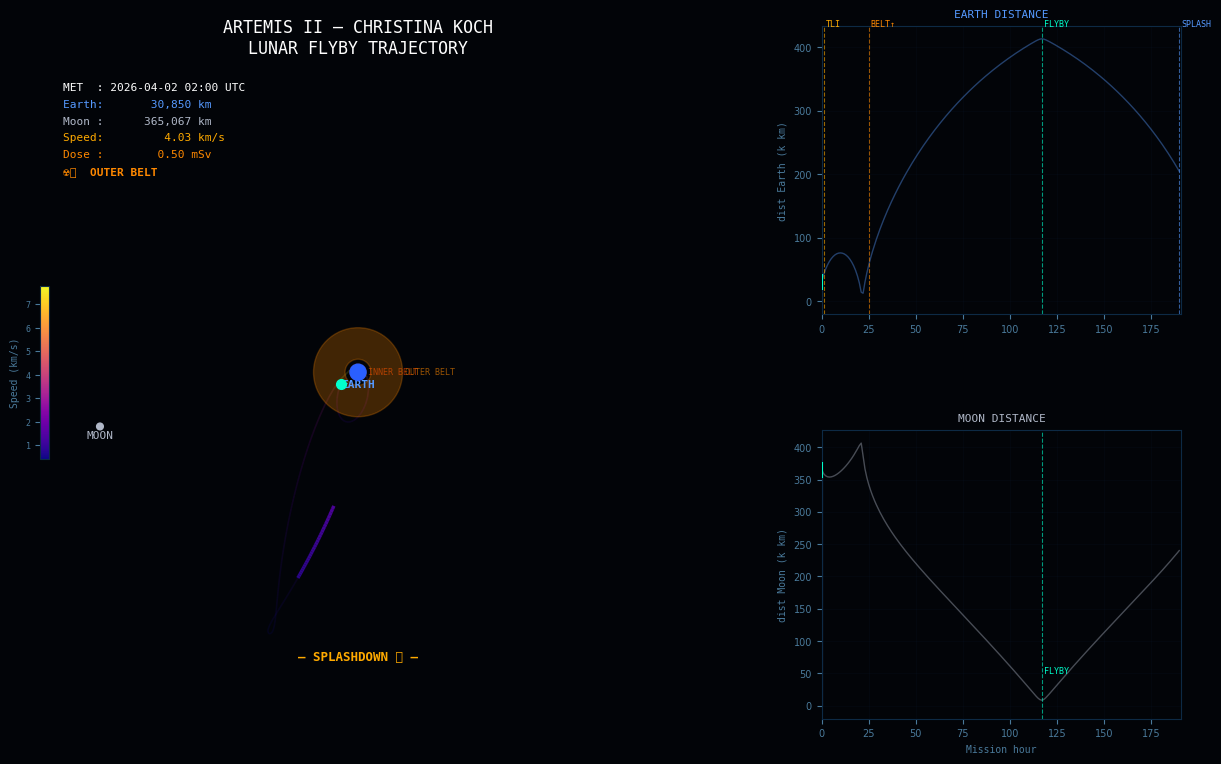

In [57]:

plt.rcParams['animation.embed_limit'] = 50

# ── Figure with two panels ────────────────────────────────────
fig = plt.figure(figsize=(16, 9), facecolor='#020408')
gs = gridspec.GridSpec(2, 2,
                        width_ratios=[2, 1],
                        height_ratios=[1, 1],
                        hspace=0.4, wspace=0.3)

ax    = fig.add_subplot(gs[:, 0])   # trajectory — full left column
ax_ed = fig.add_subplot(gs[0, 1])   # Earth distance — top right
ax_md = fig.add_subplot(gs[1, 1])   # Moon distance — bottom right

# ── Style all axes ────────────────────────────────────────────
for a in [ax, ax_ed, ax_md]:
    a.set_facecolor('#020408')
    a.tick_params(colors='#4a7a9b', labelsize=7)
    for spine in a.spines.values():
        spine.set_color('#0d2a45')

ax.set_aspect('equal')
limit = 450000
ax.set_xlim(-limit, limit)
ax.set_ylim(-limit, limit)
ax.axis('off')

# ── Speed colormap ────────────────────────────────────────────
df['speed'] = np.sqrt(df['vx']**2 + df['vy']**2 + df['vz']**2)
speed_min = df['speed'].min()
speed_max = df['speed'].max()
cmap = plt.cm.plasma
norm = mcolors.Normalize(vmin=speed_min, vmax=speed_max)

# Full faint trajectory
points = np.array([df['x'], df['y']]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
speeds_norm = norm(df['speed'].values[:-1])
colors_full = cmap(speeds_norm)
colors_full[:, 3] = 0.15
full_trail = LineCollection(segments, colors=colors_full,
                             linewidth=1.2, zorder=2)
ax.add_collection(full_trail)

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.25, pad=0.01, location='left')
cbar.set_label('Speed (km/s)', color='#4a7a9b', fontsize=7,
               fontfamily='monospace')
cbar.ax.yaxis.set_tick_params(color='#4a7a9b', labelsize=6)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#4a7a9b',
         fontsize=6, fontfamily='monospace')
cbar.outline.set_edgecolor('#0d2a45')

# ── Van Allen Belts ───────────────────────────────────────────
INNER_START = 7371
INNER_END   = 12371
OUTER_START = 19371
OUTER_END   = 66371

inner_belt = plt.matplotlib.patches.Annulus(
    (0, 0), INNER_END, INNER_END - INNER_START,
    color='#ff4400', alpha=0.15, zorder=3)
ax.add_patch(inner_belt)
ax.text(INNER_END + 3000, 0, 'INNER BELT', color='#ff4400',
        fontsize=6, fontfamily='monospace', alpha=0.6, va='center')

outer_belt = plt.matplotlib.patches.Annulus(
    (0, 0), OUTER_END, OUTER_END - OUTER_START,
    color='#ff8800', alpha=0.08, zorder=3)
ax.add_patch(outer_belt)
ax.text(OUTER_END + 3000, 0, 'OUTER BELT', color='#ff8800',
        fontsize=6, fontfamily='monospace', alpha=0.6, va='center')

# ── Earth ─────────────────────────────────────────────────────
earth = plt.Circle((0, 0), 12000, color='#2a5fff', zorder=5)
ax.add_patch(earth)
ax.text(0, -22000, 'EARTH', color='#5599ff', fontsize=8,
        ha='center', fontfamily='monospace', fontweight='bold')

# ── Moon ──────────────────────────────────────────────────────
moon_patch = plt.Circle((df['mx'][0], df['my'][0]), 5000,
                          color='#b0b8c8', zorder=5)
ax.add_patch(moon_patch)
moon_label = ax.text(0, 0, 'MOON', color='#b0b8c8', fontsize=8,
                     ha='center', fontfamily='monospace', zorder=6)

# ── Orion ─────────────────────────────────────────────────────
orion_dot, = ax.plot([], [], 'o', color='#00ffcc', markersize=7, zorder=10)
live_trail = LineCollection([], linewidth=2.5, zorder=9)
ax.add_collection(live_trail)

# ── Info texts ────────────────────────────────────────────────
time_text       = ax.text(-440000, 420000, '', color='white',
                           fontsize=8, fontfamily='monospace', zorder=11)
dist_earth_text = ax.text(-440000, 395000, '', color='#5599ff',
                           fontsize=8, fontfamily='monospace', zorder=11)
dist_moon_text  = ax.text(-440000, 370000, '', color='#b0b8c8',
                           fontsize=8, fontfamily='monospace', zorder=11)
speed_text      = ax.text(-440000, 345000, '', color='#ffaa00',
                           fontsize=8, fontfamily='monospace', zorder=11)
rad_text        = ax.text(-440000, 320000, '', color='#ff4400',
                           fontsize=8, fontfamily='monospace', zorder=11)
belt_status     = ax.text(-440000, 295000, '', color='#ff8800',
                           fontsize=8, fontfamily='monospace', zorder=11,
                           fontweight='bold')
record_text     = ax.text(0, 0, '', color='#00ffcc', fontsize=9,
                           fontfamily='monospace', ha='center',
                           fontweight='bold', zorder=12)

# Mission phase label on trajectory
phase_label = ax.text(0, -430000, '', color='#ffaa00', fontsize=9,
                       fontfamily='monospace', ha='center',
                       fontweight='bold', zorder=12)

ax.set_title('ARTEMIS II — CHRISTINA KOCH\nLUNAR FLYBY TRAJECTORY',
             color='white', fontsize=12, fontfamily='monospace', pad=12)

# ── Telemetry panels ──────────────────────────────────────────
time_axis = np.arange(len(df))

# Earth distance plot
ax_ed.plot(time_axis, df['dist_earth']/1000,
           color='#5599ff', linewidth=1, alpha=0.4)
ax_ed.set_ylabel('dist Earth (k km)', color='#4a7a9b',
                  fontsize=7, fontfamily='monospace')
ax_ed.set_title('EARTH DISTANCE', color='#5599ff',
                 fontsize=8, fontfamily='monospace', pad=6)
ax_ed.grid(alpha=0.1, color='#0d2a45')
ax_ed.set_xlim(0, len(df))
ax_ed.yaxis.label.set_color('#4a7a9b')

# Key event lines on Earth distance
for idx, label, color in [
    (1,   'TLI',     '#ffaa00'),
    (25,  'BELT↑',   '#ff8800'),
    (117, 'FLYBY',   '#00ffcc'),
    (190, 'SPLASH',  '#5599ff'),
]:
    ax_ed.axvline(x=idx, color=color, linewidth=0.8,
                   linestyle='--', alpha=0.6)
    ax_ed.text(idx+1, ax_ed.get_ylim()[1] if ax_ed.get_ylim()[1] > 0 else 400,
               label, color=color, fontsize=6, fontfamily='monospace')

# Moon distance plot
ax_md.plot(time_axis, df['dist_moon']/1000,
           color='#b0b8c8', linewidth=1, alpha=0.4)
ax_md.set_ylabel('dist Moon (k km)', color='#4a7a9b',
                  fontsize=7, fontfamily='monospace')
ax_md.set_xlabel('Mission hour', color='#4a7a9b',
                  fontsize=7, fontfamily='monospace')
ax_md.set_title('MOON DISTANCE', color='#b0b8c8',
                 fontsize=8, fontfamily='monospace', pad=6)
ax_md.grid(alpha=0.1, color='#0d2a45')
ax_md.set_xlim(0, len(df))
ax_md.axvline(x=117, color='#00ffcc', linewidth=0.8,
               linestyle='--', alpha=0.6)
ax_md.text(118, 50, 'FLYBY', color='#00ffcc',
           fontsize=6, fontfamily='monospace')

# Moving cursors on telemetry
cursor_ed, = ax_ed.plot([], [], '|', color='#00ffcc',
                         markersize=12, markeredgewidth=1.5, zorder=5)
cursor_md, = ax_md.plot([], [], '|', color='#00ffcc',
                         markersize=12, markeredgewidth=1.5, zorder=5)

# Filled area under cursor (progress indicator)
ed_fill = ax_ed.fill_between([], [], alpha=0)
md_fill = ax_md.fill_between([], [], alpha=0)

max_dist_idx = df['dist_earth'].idxmax()

# ── Radiation rates ───────────────────────────────────────────
OUTER_BELT_RATE = 0.5
DEEP_SPACE_RATE = 0.02

def get_rad_rate(dist_earth):
    if dist_earth < INNER_END:
        return 2.0
    elif dist_earth < OUTER_END:
        return OUTER_BELT_RATE
    else:
        return DEEP_SPACE_RATE

# Phase labels
PHASES = {
    1:   'TLI BURN 🔥',
    2:   'PROXIMITY OPS',
    25:  'OUTER BELT EXIT ↑',
    117: 'LUNAR FLYBY 🌕',
    190: 'SPLASHDOWN 🌊',
}

# ── Animate ───────────────────────────────────────────────────
def animate(i):
    global ed_fill, md_fill

    # Moon
    moon_patch.center = (df['mx'][i], df['my'][i])
    moon_label.set_position((df['mx'][i], df['my'][i] - 18000))

    # Orion
    orion_dot.set_data([df['x'][i]], [df['y'][i]])

    # Colored trail
    trail_start = max(0, i-30)
    trail_points = np.array([df['x'][trail_start:i+1],
                              df['y'][trail_start:i+1]]).T.reshape(-1, 1, 2)
    if len(trail_points) > 1:
        trail_segs = np.concatenate([trail_points[:-1], trail_points[1:]], axis=1)
        trail_speeds = norm(df['speed'].values[trail_start:i])
        trail_colors = cmap(trail_speeds)
        trail_colors[:, 3] = 0.9
        live_trail.set_segments(trail_segs)
        live_trail.set_colors(trail_colors)

    # Speed & radiation
    speed = df['speed'][i]
    total_rad = sum(get_rad_rate(df['dist_earth'][j]) for j in range(i+1))
    dist = df['dist_earth'][i]

    # Belt glow & status
    if dist < INNER_END:
        status = '⚠️  INNER BELT'
        inner_belt.set_alpha(0.5)
        outer_belt.set_alpha(0.08)
        belt_color = '#ff4400'
    elif dist < OUTER_END:
        status = '☢️  OUTER BELT'
        outer_belt.set_alpha(0.25)
        inner_belt.set_alpha(0.15)
        belt_color = '#ff8800'
    else:
        status = '✦  DEEP SPACE'
        outer_belt.set_alpha(0.08)
        inner_belt.set_alpha(0.15)
        belt_color = '#4a7a9b'

    # Update info texts
    time_text.set_text(f"MET  : {df['time'][i].strftime('%Y-%m-%d %H:%M')} UTC")
    dist_earth_text.set_text(f"Earth: {df['dist_earth'][i]:>12,.0f} km")
    dist_moon_text.set_text(f"Moon : {df['dist_moon'][i]:>12,.0f} km")
    speed_text.set_text(f"Speed: {speed:>12.2f} km/s")
    rad_text.set_text(f"Dose : {total_rad:>11.2f} mSv")
    rad_text.set_color(belt_color)
    belt_status.set_text(status)
    belt_status.set_color(belt_color)

    # Mission phase label
    if i in PHASES:
        phase_label.set_text(f'— {PHASES[i]} —')
    elif i > max(PHASES.keys()) or (i not in PHASES and
         not any(abs(i-k) < 5 for k in PHASES)):
        phase_label.set_text('')

    # Historic record
    if i == max_dist_idx:
        record_text.set_position((df['x'][i], df['y'][i] + 25000))
        record_text.set_text('★ HISTORIC RECORD\n☢️ Furthest woman from Earth')
    elif i > max_dist_idx + 3:
        record_text.set_text('')

    # ── Telemetry cursors ─────────────────────────────────────
    cursor_ed.set_data([i], [df['dist_earth'][i]/1000])
    cursor_md.set_data([i], [df['dist_moon'][i]/1000])

    # Progress fill
    ed_fill.remove()
    md_fill.remove()
    ed_fill = ax_ed.fill_between(time_axis[:i+1],
                                  df['dist_earth'][:i+1]/1000,
                                  color='#5599ff', alpha=0.15)
    md_fill = ax_md.fill_between(time_axis[:i+1],
                                  df['dist_moon'][:i+1]/1000,
                                  color='#b0b8c8', alpha=0.15)

    return (moon_patch, moon_label, orion_dot, live_trail,
            inner_belt, outer_belt,
            time_text, dist_earth_text, dist_moon_text,
            speed_text, rad_text, belt_status,
            record_text, phase_label,
            cursor_ed, cursor_md)

anim = FuncAnimation(fig, animate, frames=len(df), interval=80, blit=False)
plt.tight_layout()

print("Saving... ⏳ this may take 1-2 minutes")
html_content = anim.to_jshtml()
with open('artemis_ii_telemetry.html', 'w') as f:
    f.write(html_content)

print("Done! ✅")
FileLink('artemis_ii_telemetry.html')

In [42]:
# Where does Orion cross out of the outer belt?
outer_belt_end = 6371 + 60000  # km from Earth center

in_outer = df[df['dist_earth'] < outer_belt_end]
print(f"Orion inside outer belt for first {len(in_outer)} hours")
print(f"Exits outer belt at: {in_outer['time'].iloc[-1]}")
print(f"Distance at exit: {in_outer['dist_earth'].iloc[-1]:.0f} km")

Orion inside outer belt for first 16 hours
Exits outer belt at: 2026-04-03 03:00:00
Distance at exit: 57132 km
